## Percobaan 1 — Dataset sederhana

Hierarchical Clustering membentuk hierarki klaster dengan menggabungkan data secara
bertahap. Pada percobaan pertama digunakan enam titik, yaitu `a` sampai `f`, agar
jarak dan proses penggabungan mudah diamati.

### 1. Distance matrix dan dendrogram Single Linkage

Jarak antartitik dihitung menggunakan Euclidean Distance. `Single linkage`
menentukan jarak antarklaster berdasarkan pasangan anggota yang **paling dekat**.
Distance matrix dan dendrogram yang dihasilkan mengikuti output pada modul.

=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


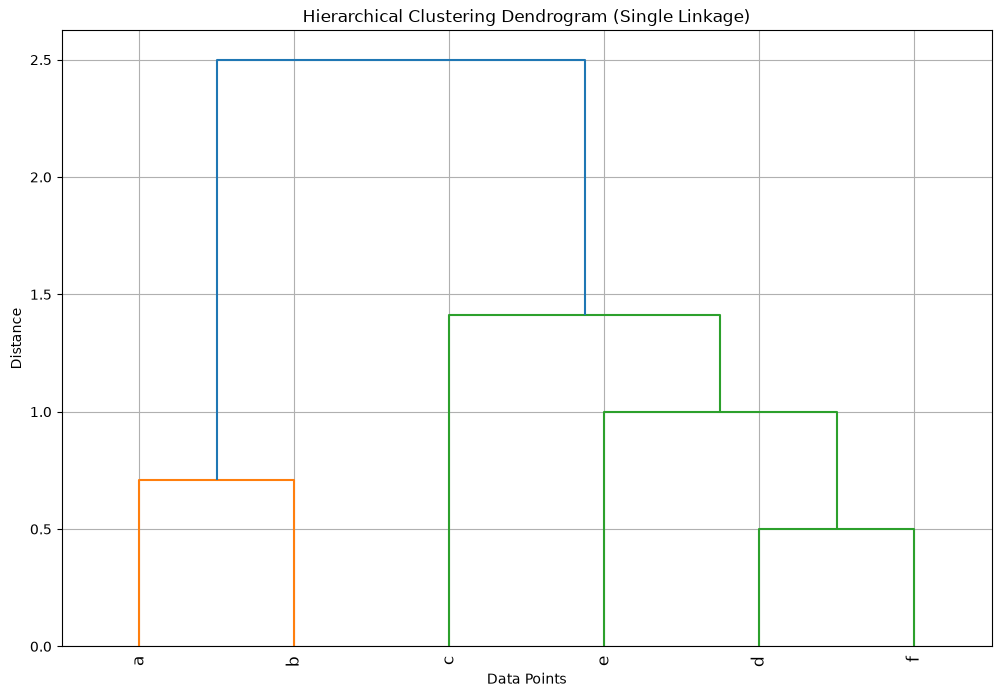

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5]   # f
])

distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(
    squareform(distance_matrix),
    columns=['a', 'b', 'c', 'd', 'e', 'f'],
    index=['a', 'b', 'c', 'd', 'e', 'f']
)

print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

linked = linkage(data, method='single')


plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(
    linked,
    labels=['a', 'b', 'c', 'd', 'e', 'f'],
    leaf_rotation=90
)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

## Percobaan 2 — Dataset Mall Customers

Percobaan kedua mengelompokkan pelanggan berdasarkan dua fitur:

- `Annual Income (k$)`
- `Spending Score (1-100)`

### 2. Membaca dataset

Dataset dibaca dengan pandas dan lima baris pertama ditampilkan untuk memastikan
struktur data sama dengan modul.

In [2]:
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 3. Memilih Annual Income dan Spending Score

`iloc[:, [3, 4]]` mengambil kolom indeks ke-3 dan ke-4. Hasilnya disimpan sebagai
array NumPy untuk proses standardisasi dan clustering.

In [3]:
x = df.iloc[:, [3, 4]].values

### 4. Standardisasi data

`StandardScaler` mengubah setiap fitur agar memiliki rata-rata mendekati nol dan
standar deviasi satu. Standardisasi mencegah fitur dengan skala lebih besar
mendominasi Euclidean Distance. Output `(200, 2)` menunjukkan 200 pelanggan dan
dua fitur.

In [4]:
from sklearn.preprocessing import StandardScaler
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape


(200, 2)

### 5. Membentuk hierarki dengan Complete Linkage

`Complete linkage` mengukur jarak dua klaster berdasarkan pasangan anggota yang
**paling jauh**. Metrik jarak yang digunakan adalah Euclidean Distance, sama
seperti pada modul.

In [5]:
from scipy.cluster.hierarchy import linkage, dendrogram

clustering = linkage(
    scaled_data,
    method="complete",
    metric="euclidean"
)

### 6. Menampilkan dendrogram Mall Customers

Dendrogram memperlihatkan urutan penggabungan seluruh pelanggan. Warna cabang pada
output membentuk tiga kelompok utama seperti pada modul. Sumbu vertikal
menunjukkan jarak ketika dua klaster digabung.

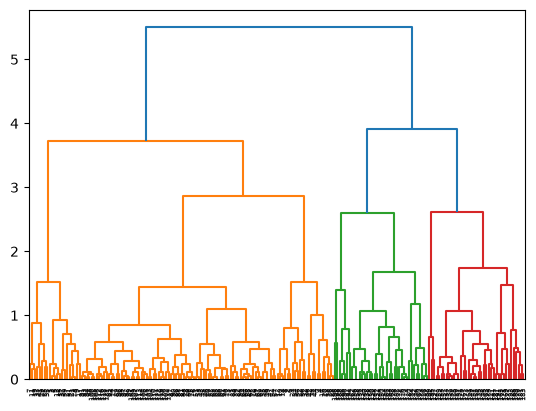

In [6]:
import matplotlib.pyplot as plt

dendrogram(clustering)
plt.show()

# Tugas: Perbandingan Metode Linkage

Pada dataset sederhana, hasil single linkage dibandingkan dengan complete linkage
dan average linkage. Data dan label yang digunakan tetap sama agar perbedaannya
hanya berasal dari cara menghitung jarak antarklaster.

### Dendrogram Complete Linkage

Complete linkage memakai jarak **terjauh** antaranggota dari dua klaster. Metode
ini cenderung menghasilkan klaster yang lebih kompak dan tidak mudah membentuk
rantai panjang.

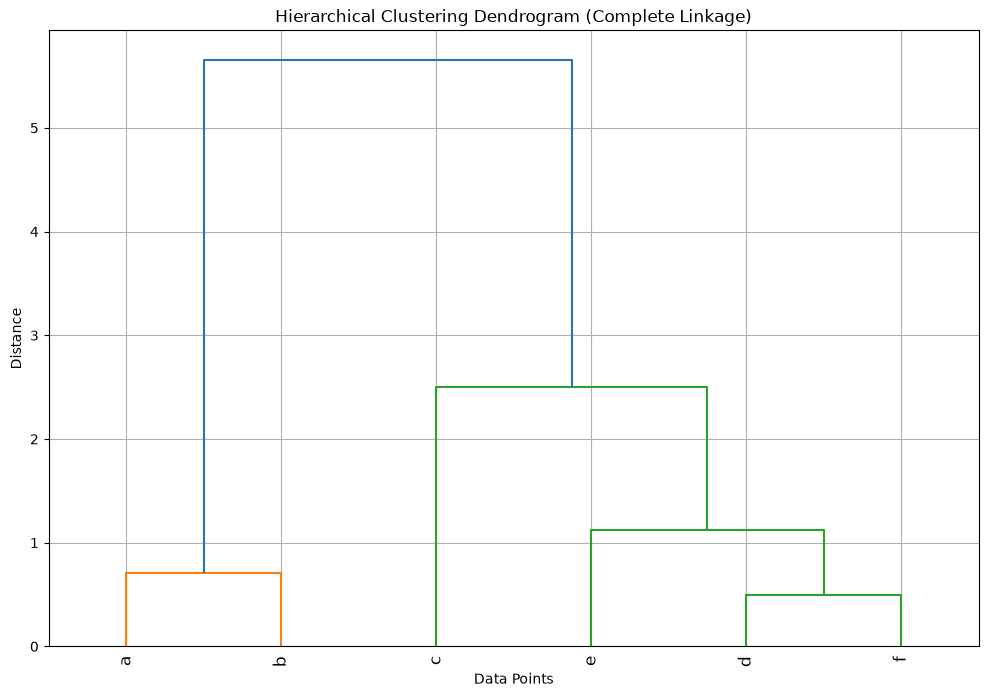

In [7]:
complete_linked = linkage(data, method='complete')

plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
dendrogram(
    complete_linked,
    labels=['a', 'b', 'c', 'd', 'e', 'f'],
    leaf_rotation=90
)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

### Dendrogram Average Linkage

Average linkage menggunakan **rata-rata seluruh jarak pasangan anggota** dari dua
klaster. Hasilnya biasanya menjadi kompromi antara single linkage dan complete
linkage.

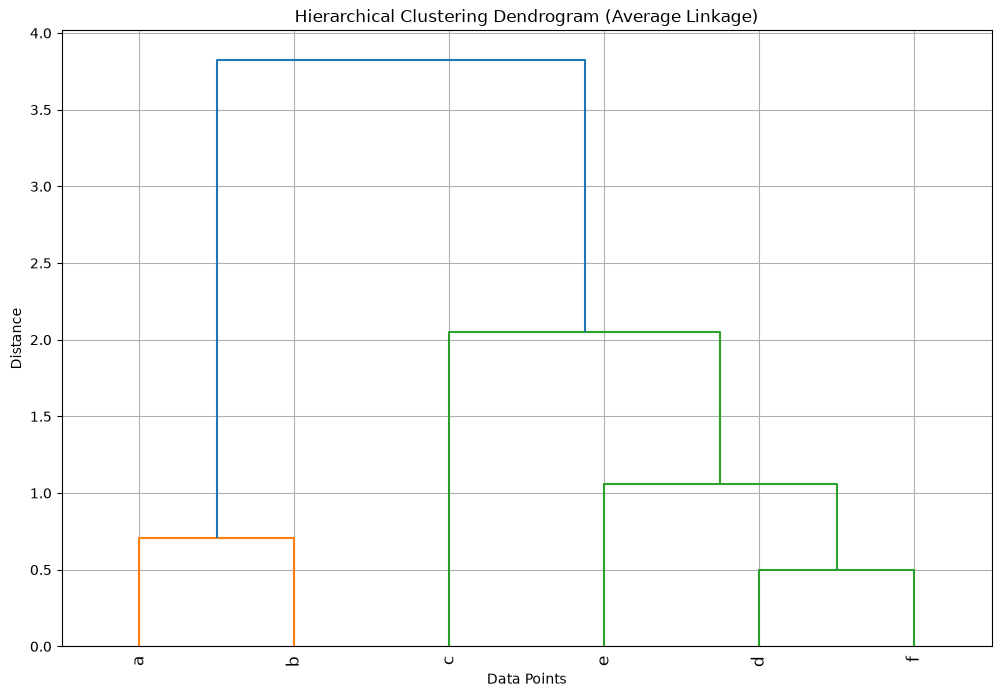

In [8]:
average_linked = linkage(data, method='average')

plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
dendrogram(
    average_linked,
    labels=['a', 'b', 'c', 'd', 'e', 'f'],
    leaf_rotation=90
)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

### Perbandingan ketiga dendrogram

Ketiga dendrogram ditampilkan berdampingan agar perbedaan tinggi penggabungan dan
struktur hierarkinya mudah dibandingkan.

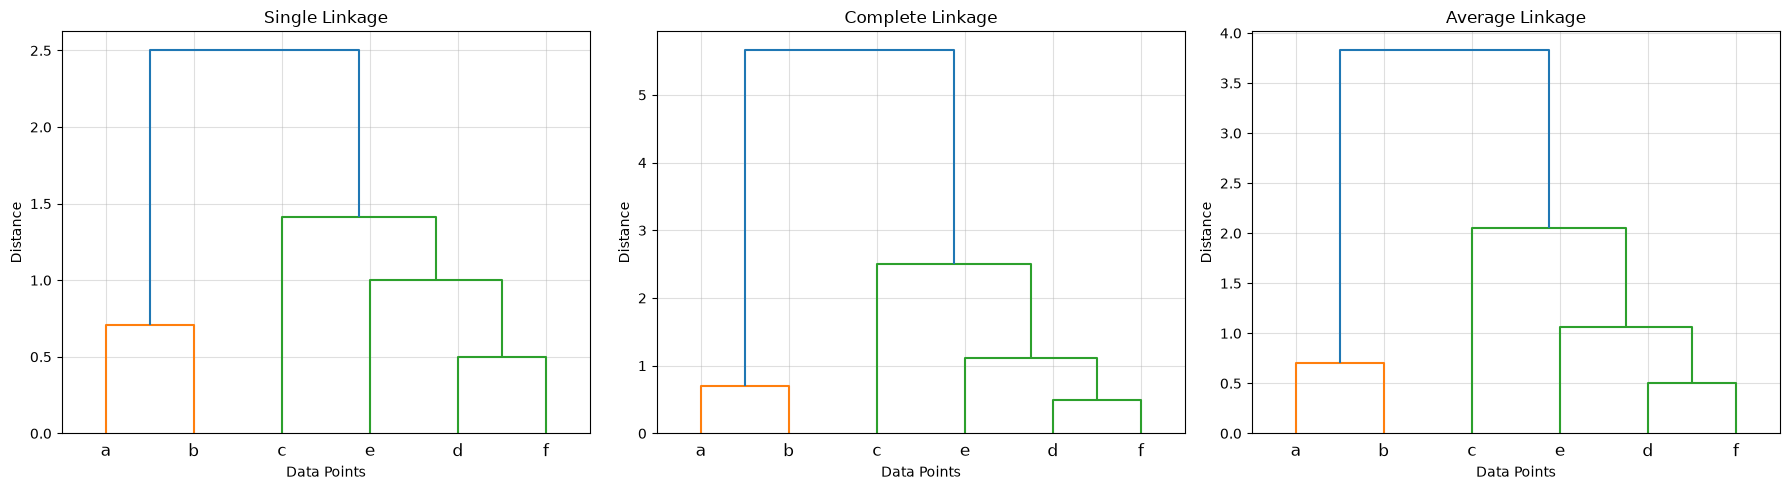

In [9]:
methods = {
    "Single Linkage": linkage(data, method="single"),
    "Complete Linkage": linkage(data, method="complete"),
    "Average Linkage": linkage(data, method="average")
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['a', 'b', 'c', 'd', 'e', 'f']

for ax, (title, result) in zip(axes, methods.items()):
    dendrogram(result, labels=labels, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Data Points")
    ax.set_ylabel("Distance")
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()